# 🏠 Ames Housing — Pipeline Completo
## Limpeza de Dados + Feature Engineering + Regressão Linear

**Objetivo:** Preparar o dataset de Ames Housing para um modelo de regressão linear capaz de prever o preço de venda de imóveis (`SalePrice`) com a maior performance possível.

**Estrutura do notebook:**

| # | Fase | O que faz |
|---|------|-----------|
| 1 | Imports & Configuração | Bibliotecas e constantes |
| 2 | Valores Ausentes | Distingue NaN semântico de dado faltante |
| 3 | Outliers | Remove registros e transforma o target |
| 4 | Feature Engineering | Cria variáveis derivadas e interações |
| 5 | Encoding | Converte categóricas para numéricas |
| 6 | Transformação & Escala | Normaliza distribuições e escalona |
| 7 | Modelagem | Ridge, Lasso e tuning por cross-validation |
| 8 | Submissão | Predição final e exportação |

> 📌 **Contexto:** O dataset possui ~80 variáveis descrevendo atributos físicos, de localização e de condição de ~1.460 imóveis vendidos em Ames, Iowa (EUA) entre 2006 e 2010.

---
## Fase 0 — Imports e Configuração

Importamos as bibliotecas essenciais:
- **`numpy` / `pandas`**: manipulação de dados
- **`scipy.stats`**: cálculo de assimetria (skewness) das distribuições
- **`sklearn`**: pré-processamento, modelos e avaliação
- **`statsmodels`**: Variance Inflation Factor (VIF) para detectar multicolinearidade
- **`warnings`**: suprime avisos repetitivos que não afetam o resultado

In [1539]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import stats
from xgboost import XGBRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
print("Bibliotecas carregadas com sucesso ✓")

Bibliotecas carregadas com sucesso ✓


---
## Carregando os Dados

Carregamos treino e teste separadamente.  
A coluna `Id` é removida (é apenas um índice) e o `SalePrice` é separado como variável target.

> ⚠️ Todo o pipeline será ajustado (**fit**) apenas no conjunto de treino e apenas **aplicado** (transform) no teste, para evitar **data leakage** — o vazamento de informação do futuro para o modelo.

In [1540]:
df_train_raw = pd.read_csv("train_student.csv")
df_test_raw  = pd.read_csv("test_student.csv")

test_ids = df_test_raw["Id"].copy()

# Separar target antes de qualquer transformação
y_raw    = df_train_raw["SalePrice"].copy()
df_train = df_train_raw.drop(columns=["SalePrice", "Id"]).copy()
df_test  = df_test_raw.drop(columns=["Id"]).copy()

print(f"Treino: {df_train.shape[0]} linhas × {df_train.shape[1]} colunas")
print(f"Teste:  {df_test.shape[0]} linhas × {df_test.shape[1]} colunas")
print(f"\nDistribuição do target (SalePrice):")
print(y_raw.describe().apply(lambda x: f"${x:,.0f}"))

Treino: 1022 linhas × 79 colunas
Teste:  438 linhas × 79 colunas

Distribuição do target (SalePrice):
count      $1,022
mean     $181,313
std       $77,617
min       $34,900
25%      $130,000
50%      $165,000
75%      $215,000
max      $745,000
Name: SalePrice, dtype: str


---
## Fase 1 — Tratamento de Valores Ausentes

### Por que isso importa?
A maioria dos algoritmos não lida bem com `NaN`. Em regressão linear, um único valor ausente em uma linha faz com que toda aquela observação seja descartada por padrão.

### O ponto-chave deste dataset
Diferente do habitual, **a maioria dos `NaN` aqui não significa "dado faltante"** — ela significa **"essa propriedade não existe"**. Por exemplo:
- `FireplaceQu = NaN` → o imóvel não tem lareira
- `GarageType = NaN` → o imóvel não tem garagem
- `PoolQC = NaN` → o imóvel não tem piscina

Tratar esses casos como "dado desconhecido" e imputar com a mediana seria um **erro conceitual grave**. A estratégia correta é preencher com `"None"` (categórico) ou `0` (numérico).

### Casos que são dados realmente faltantes
- `LotFrontage`: metros de rua conectados ao lote. Faz sentido não ser zero — usamos a **mediana por bairro**, que é muito mais precisa do que a mediana global, já que lotes de um mesmo bairro tendem a ter tamanhos similares.
- `GarageYrBlt`: quando há garagem mas o ano não foi registrado, substituímos pelo `YearBuilt`.

# Quantos valores ausentes existem? (Em porcentagem)

In [1541]:
# How many missing values are there in each column?
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100

missing_data = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("Missing Values (%):")
if not missing_data.empty:
    print(missing_data.map("{:.2f}%".format))
else:
    print("No missing values found!")

Missing Values (%):
PoolQC          99.51%
MiscFeature     96.09%
Alley           93.54%
Fence           80.23%
MasVnrType      57.73%
FireplaceQu     47.65%
LotFrontage     18.59%
GarageType       5.28%
GarageYrBlt      5.28%
GarageFinish     5.28%
GarageQual       5.28%
GarageCond       5.28%
BsmtCond         2.54%
BsmtFinType1     2.54%
BsmtExposure     2.54%
BsmtQual         2.54%
BsmtFinType2     2.54%
MasVnrArea       0.29%
Electrical       0.10%
dtype: str


In [1542]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Trata valores ausentes distinguindo NaN semântico (ausência da feature)
    de dado genuinamente faltante.
    """
    df = df.copy()

    # ── NaN semântico em categóricas: ausência = "não tem" ──────────────────
    # Preencher com "None" preserva a informação: o imóvel não tem aquela feature.
    # Se usássemos a moda, estaríamos inventando features que não existem.
    excessive_nulls = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'
    ]
    df.drop(columns=[c for c in excessive_nulls if c in df.columns], inplace=True)
    cat_none = [
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    ]
    for col in cat_none:
        if col in df.columns:
            df[col] = df[col].fillna("None")
    # ── LotFrontage: dado genuinamente faltante ──────────────────────────────
    # Coloca 0 pois se não tem significa que não tem metragem de frente, ou seja, 0 metros.
    df["LotFrontage"] = df["LotFrontage"].fillna(0)

    # ── GarageYrBlt: quando há garagem mas o ano não foi registrado ──────────
    # Assumir que a garagem foi construída junto com a casa é a melhor estimativa.
    if "GarageYrBlt" in df.columns:
        df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])

    # ── Variáveis com 1-2 NaN: moda ─────────────────────────────────────────
    # Com tão poucos casos, a moda é suficiente e não distorce nada.
    mode_cols = [
        "Electrical", "MasVnrArea"
    ]
    for col in mode_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df

df_train = handle_missing_values(df_train)
df_test  = handle_missing_values(df_test)

# Verificação: nenhuma coluna deve ter NaN restante (exceto as que ainda
# passarão por encoding, que serão resolvidas a seguir)
nan_restante = df_train.isnull().sum()
print("Colunas com NaN restante no treino:")
print(nan_restante[nan_restante > 0] if nan_restante.sum() > 0 else "Nenhuma ✓")

Colunas com NaN restante no treino:
Nenhuma ✓


# Exploratory Data Analysis

## Analisando Fireplaces

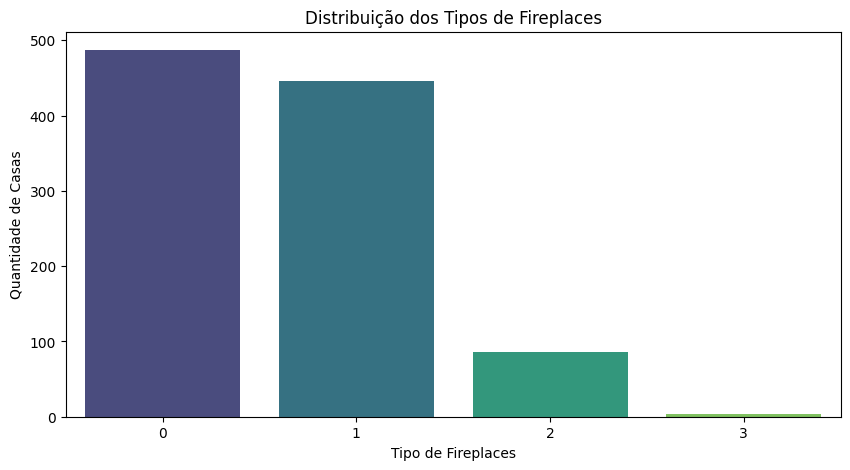

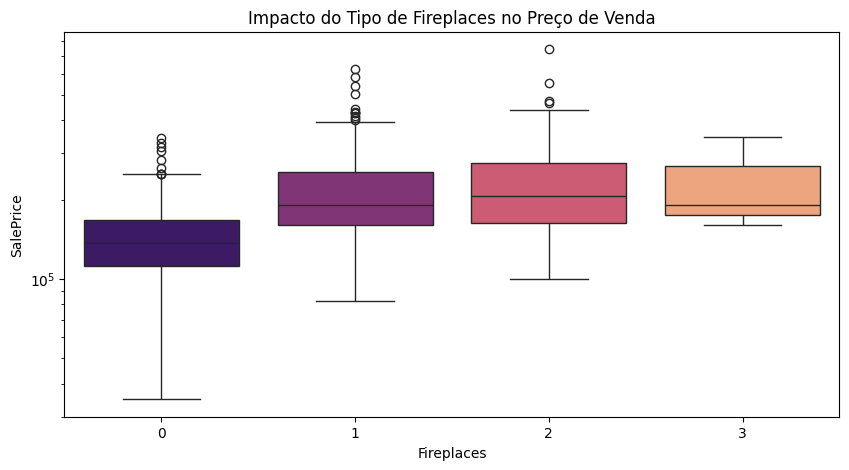

In [1543]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gráfico de Contagem (Frequência)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train_raw, x='Fireplaces', palette='viridis', order=df_train_raw['Fireplaces'].value_counts().index)
plt.title('Distribuição dos Tipos de Fireplaces')
plt.xlabel('Tipo de Fireplaces')
plt.ylabel('Quantidade de Casas')
plt.show()

# 2. Gráfico de Boxplot (Fireplaces vs Preço)
# Isso te ajuda a ver se algum tipo de fireplaces valoriza mais a casa
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train_raw, x='Fireplaces', y='SalePrice', palette='magma')
plt.title('Impacto do Tipo de Fireplaces no Preço de Venda')
plt.yscale('log') # Usamos escala log para visualizar melhor os outliers
plt.show()

# Analisando impacto da fundação no preço

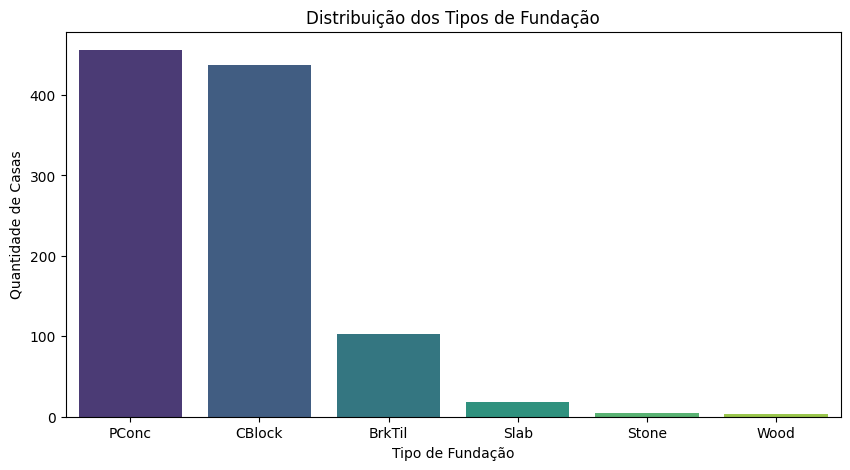

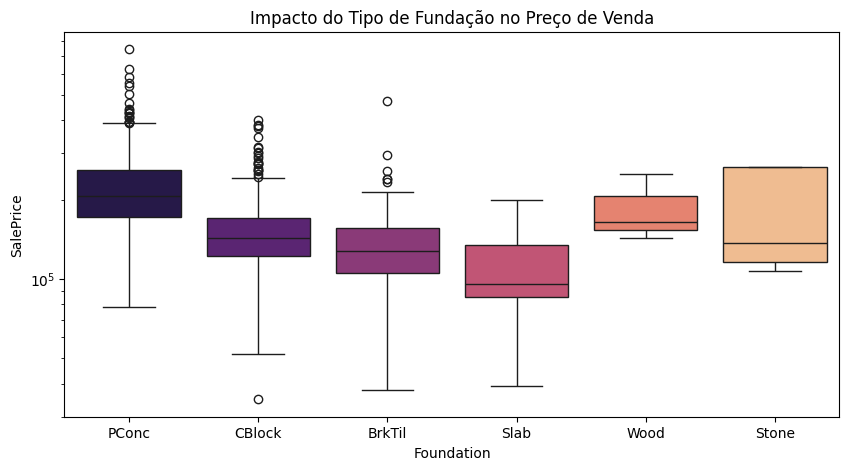

In [1544]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gráfico de Contagem (Frequência)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train_raw, x='Foundation', palette='viridis', order=df_train_raw['Foundation'].value_counts().index)
plt.title('Distribuição dos Tipos de Fundação')
plt.xlabel('Tipo de Fundação')
plt.ylabel('Quantidade de Casas')
plt.show()

# 2. Gráfico de Boxplot (Fundação vs Preço)
# Isso te ajuda a ver se algum tipo de fundação valoriza mais a casa
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train_raw, x='Foundation', y='SalePrice', palette='magma')
plt.title('Impacto do Tipo de Fundação no Preço de Venda')
plt.yscale('log') # Usamos escala log para visualizar melhor os outliers
plt.show()

In [1545]:
# Agrupando o que é raro em 'Other' para dar robustez ao modelo
df_train['Foundation'] = df_train['Foundation'].replace(['Slab', 'Stone', 'Wood'], 'Other')

# Mantendo PConc, CBlock e BrkTil como categorias separadas, 
# pois elas têm volume e comportamentos de preço distintos.

# Analisando área vs preço

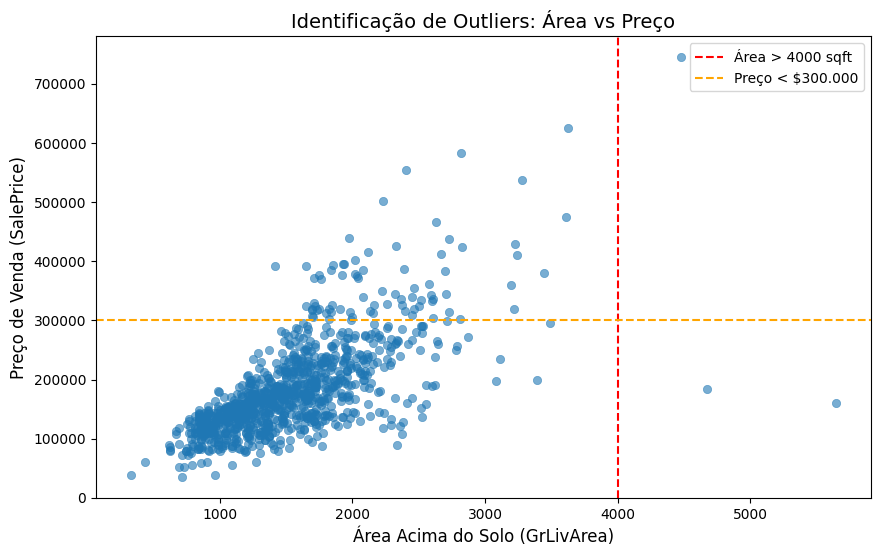

In [1546]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configura o tamanho da figura
plt.figure(figsize=(10, 6))

# Plota o gráfico de dispersão (Área vs Preço)
# Supondo que o nome do seu dataframe seja df_train
sns.scatterplot(x=df_train['GrLivArea'], y=y_raw, 
                alpha=0.6, edgecolor=None)

# Linhas de referência para destacar a zona de perigo
plt.axvline(x=4000, color='red', linestyle='--', label='Área > 4000 sqft')
plt.axhline(y=300000, color='orange', linestyle='--', label='Preço < $300.000')

plt.title('Identificação de Outliers: Área vs Preço', fontsize=14)
plt.xlabel('Área Acima do Solo (GrLivArea)', fontsize=12)
plt.ylabel('Preço de Venda (SalePrice)', fontsize=12)
plt.legend()

plt.show()

---
## Fase 2 — Remoção de Outliers e Transformação do Target

### 2a. Outliers no conjunto de treino
O dataset contém dois registros notórios: imóveis com área habitável (`GrLivArea`) acima de 4.000 sqft, mas vendidos por valores surpreendentemente baixos. Isso ocorreu porque foram vendas parciais/atípicas — e esses pontos **puxam a reta de regressão para longe da maioria dos dados**, prejudicando muito a performance geral.

> ⚠️ Outliers são removidos **somente do treino**. No conjunto de teste, precisamos prever para todos os imóveis, independentemente de serem atípicos.

### 2b. Transformação logarítmica do target (`SalePrice`)
O `SalePrice` tem uma distribuição **assimétrica à direita** (right-skewed): há muitas casas baratas e poucas muito caras. Isso viola uma premissa da regressão linear (resíduos normalmente distribuídos) e faz o modelo subestimar preços altos.

A solução é aplicar **`log1p(SalePrice)`**, que:
1. Comprime os valores extremos, aproximando a distribuição de uma normal
2. Faz com que o modelo minimize o erro relativo (percentual) e não o erro absoluto
3. Melhora significativamente o RMSE no leaderboard do Kaggle

Na hora de prever, basta reverter com `expm1()` para recuperar os preços originais.

In [1547]:
def remove_outliers(df: pd.DataFrame, target: pd.Series):
    """
    Remove os outliers documentados do dataset Ames Housing.
    Aplicar APENAS no conjunto de treino.
    
    Critério: casas com GrLivArea > 4.000 sqft e preço < $300k
    são vendas atípicas que distorcem o modelo.
    """
    mask = ~((df["GrLivArea"] > 4000) & (target < 300_000))
    return df[mask].reset_index(drop=True), target[mask].reset_index(drop=True)

def log_transform_target(target: pd.Series) -> pd.Series:
    """
    Aplica log1p no SalePrice para normalizar a distribuição assimétrica.
    log1p(x) = log(1 + x), que é seguro mesmo para x=0.
    """
    return np.log1p(target)

def inverse_transform_target(predictions: np.ndarray) -> np.ndarray:
    """
    Reverte o log1p para recuperar os preços reais nas predições finais.
    expm1(x) = exp(x) - 1, operação inversa do log1p.
    """
    return np.expm1(predictions)

n_antes = len(df_train)
df_train, y_raw = remove_outliers(df_train, y_raw)
print(f"Registros removidos como outliers: {n_antes - len(df_train)}")
print(f"Registros de treino restantes: {len(df_train)}")

# Transformação logarítmica do target
y_log = log_transform_target(y_raw)
print(f"\nSalePrice original — Skewness: {stats.skew(y_raw):.3f}")
print(f"log(SalePrice)    — Skewness: {stats.skew(y_log):.3f}  (quanto mais próximo de 0, melhor)")

Registros removidos como outliers: 2
Registros de treino restantes: 1020

SalePrice original — Skewness: 1.757
log(SalePrice)    — Skewness: 0.095  (quanto mais próximo de 0, melhor)


---
## Fase 3 — Feature Engineering e Encoding de Variáveis Categóricas

Feature engineering é o processo de **criar novas variáveis a partir das existentes** para tornar os padrões dos dados mais fáceis de capturar pelo modelo.

A regressão linear só consegue aprender relações lineares entre features e target. Ao combinarmos variáveis, estamos "mostrando" ao modelo relações que ele não conseguiria descobrir sozinho.

### Estratégias utilizadas:

**1. Combinação de áreas** — o dataset tem área do porão, 1º andar e 2º andar separadas. Somá-las em `TotalSF` cria uma medida mais representativa do tamanho total da casa.

**2. Features temporais** — o ano de construção isolado não é tão informativo quanto a **idade da casa** no momento da venda. Uma casa de 1990 vendida em 2010 tem 20 anos, o que é mais direto para o modelo.

**3. Flags binárias** — indicam a simples presença de uma feature (piscina, lareira, garagem). Muitas vezes o impacto no preço é pela existência, não pelo tamanho.

**4. Interações** — `OverallQual × GrLivArea` captura que uma casa grande E de alta qualidade vale desproporcionalmente mais do que a soma dos dois fatores separados. Essa interação é uma das features mais preditivas do dataset.

**5. Remoção de redundâncias** — após criar as features derivadas, as colunas originais que foram "consumidas" são removidas para evitar multicolinearidade.

### Tipos de encoding utilizados:

**1. Mapeamento ordinal explícito** — para variáveis com ordem natural clara (qualidade, condição, etc.). Mapear `Po=1, Fa=2, TA=3, Gd=4, Ex=5` preserva a hierarquia. Usar one-hot aqui seria um erro: criaria 5 colunas binárias que "escondem" a ordem do modelo.

**2. Variáveis binárias** — `CentralAir` e `Street` já são binárias por natureza: simplesmente mapeamos para 0/1.

**3. Target encoding para `Neighborhood`** — com 25 bairros distintos, one-hot criaria 24 colunas esparsas. Target encoding substitui cada bairro pela **média do preço** das casas daquele bairro. É uma representação muito mais compacta e informativa. O risco é o **data leakage**: se calcularmos a média usando toda a coluna, o modelo "veria" o preço das casas que deveria prever. Resolvemos isso com **K-Fold out-of-fold encoding**: cada casa recebe a média calculada *sem incluir ela mesma*.

**4. One-hot encoding** — para nominais sem ordem (tipo de cobertura, fundação, etc.). Usamos `drop_first=True` para evitar a "armadilha das variáveis dummy" (multicolinearidade perfeita). O alinhamento entre treino e teste é crítico: o teste pode não ter todas as categorias, então forçamos as mesmas colunas nos dois datasets.

In [1548]:
# ── Mapeamentos (Deixe essas variáveis globais no topo) ──
QUALITY_MAP = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

ORDINAL_MAPS = {
    "ExterQual": QUALITY_MAP, "ExterCond": QUALITY_MAP,
    "BsmtQual": QUALITY_MAP, "BsmtCond": QUALITY_MAP,
    "HeatingQC": QUALITY_MAP, "KitchenQual": QUALITY_MAP,
    "GarageQual": QUALITY_MAP, "GarageCond": QUALITY_MAP,
    "BsmtExposure": {"None": 0, "No": 0, "Mn": 1, "Av": 2, "Gd": 3},
    "BsmtFinType1": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "GarageFinish": {"None": 0, "Unf": 0, "RFn": 1, "Fin": 2},
    "LotShape":     {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandContour":  {"Low": 0, "HLS": 1, "Bnk": 2, "Lvl": 3},
    "Utilities":    {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
    "LotConfig":    {"FR3": 0, "FR2": 1, "Corner": 2, "CulDSac": 3, "Inside": 4},
    "LandSlope":    {"Sev": 0, "Mod": 1, "Gtl": 2},
    "PavedDrive":   {"N": 0, "P": 1, "Y": 2},
    "Functional":   {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
}

BINARY_MAPS = {
    "CentralAir": {"Y": 1, "N": 0},
    "Street":     {"Pave": 1, "Grvl": 0},
}


# ── A Função Principal Unificada ──
def prep_and_engineer(df: pd.DataFrame) -> pd.DataFrame:
    """
    Executa todos os mapeamentos e engenharia de features de uma vez.
    Garante que Treino e Teste recebam exatamente o mesmo tratamento.
    """
    df = df.copy()

    # 1. Encodings Ordinais e Binários
    for col, mapping in ORDINAL_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)

    for col, mapping in BINARY_MAPS.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)

    # 2. Tratamento das Conditions (Flags Binárias)
    if "Condition1" in df.columns and "Condition2" in df.columns:
        df["NearRailroad"] = df[["Condition1", "Condition2"]].isin(['RRNn', 'RRAn', 'RRNe', 'RRAe']).any(axis=1).astype(int)
        df["NearPositiveFeature"] = df[["Condition1", "Condition2"]].isin(['PosN', 'PosA']).any(axis=1).astype(int)
        df["NearArteryFeedr"] = df[["Condition1", "Condition2"]].isin(['Artery', 'Feedr']).any(axis=1).astype(int)

    # 3. Tratamento da Foundation (Agrupando raros que vimos no gráfico)
    if "Foundation" in df.columns:
        df["Foundation"] = df["Foundation"].replace(['Slab', 'Stone', 'Wood'], 'Other')

    # 4. Áreas combinadas e Temporais
    df["TotalSF"] = df.get("TotalBsmtSF", 0) + df.get("1stFlrSF", 0) + df.get("2ndFlrSF", 0)
    df["TotalPorchSF"] = df.get("OpenPorchSF", 0) + df.get("EnclosedPorch", 0) + df.get("3SsnPorch", 0) + df.get("ScreenPorch", 0)
    df["TotalBathrooms"] = df.get("FullBath", 0) + 0.5 * df.get("HalfBath", 0) + df.get("BsmtFullBath", 0) + 0.5 * df.get("BsmtHalfBath", 0)
    
    yr_sold = df.get("YrSold", 2010)
    df["HouseAge"]    = (yr_sold - df["YearBuilt"]).clip(lower=0)
    df["RemodAge"]    = (yr_sold - df["YearRemodAdd"]).clip(lower=0)
    df["GarageAge"]   = (yr_sold - df.get("GarageYrBlt", df["YearBuilt"])).clip(lower=0)
    df["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

    # 5. Flags de existência e Interações
    df["Has2ndFloor"]  = (df.get("2ndFlrSF", 0) > 0).astype(int)

    df["QualxArea"]    = df["OverallQual"] * df["GrLivArea"]
    df["QualxAge"]     = df["OverallQual"] * df["HouseAge"]     
    df["OverallScore"] = df["OverallQual"] * df["OverallCond"]  
    # 6. Remoção de colunas redundantes
    df["BsmtFinScore1"] = df["BsmtFinType1"] * df.get("BsmtFinSF1", 0)
    df["BsmtFinScore2"] = df["BsmtFinType2"] * df.get("BsmtFinSF2", 0)
    
    # Soma as duas para ter uma métrica única do poder do porão da casa
    df["TotalBsmtFinScore"] = df["BsmtFinScore1"] + df["BsmtFinScore2"]

    # ── Remoção de colunas redundantes (ATUALIZADA) ──
    cols_to_drop = [
        "Condition1", "Condition2", 
        "YearBuilt", "YearRemodAdd", "GarageYrBlt",         
        "1stFlrSF", "2ndFlrSF", "TotalBsmtSF",              
        "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
        "FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath", 
        "Utilities", "MoSold", "PoolArea", "GarageCond",
        
        # O QUE ENTRA AQUI AGORA:
        "BsmtFinType1", "BsmtFinType2", "BsmtFinSF1", "BsmtFinSF2",
        "BsmtFinScore1", "BsmtFinScore2" # Dropamos as parciais e ficamos só com a Total
    ]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# ── Aplicação (Onde a mágica acontece) ──
df_train = prep_and_engineer(df_train)
df_test  = prep_and_engineer(df_test)

print(f"Features após engenharia — Treino: {df_train.shape[1]} colunas | Teste: {df_test.shape[1]} colunas")

Features após engenharia — Treino: 64 colunas | Teste: 64 colunas


In [1549]:
def target_encode_neighborhood(df_train, df_test, target, n_splits=5):
    """
    Target encoding do Neighborhood com K-Fold out-of-fold para evitar data leakage.

    Ideia: substituir cada bairro pela média do log(SalePrice) das casas daquele bairro.
    
    Problema do data leakage: se calcularmos a média usando TODAS as casas,
    o modelo aprende o preço médio do bairro incluindo a própria casa que está
    sendo predita — isso é "trapacear" e resulta em overfitting.

    Solução K-Fold OOF: dividimos o treino em k partes (folds). Para cada fold,
    calculamos a média do bairro usando APENAS as outras k-1 partes. Assim,
    cada casa recebe uma média calculada sem incluí-la.
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()
    global_mean = target.mean()

    oof_encoded = np.zeros(len(df_train))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df_train):
        # Calcula média por bairro usando apenas o fold de treino
        fold_means = (
            df_train.iloc[train_idx]
            .assign(target=target.iloc[train_idx])
            .groupby("Neighborhood")["target"].mean()
        )
        # Aplica no fold de validação; bairros desconhecidos recebem a média global
        oof_encoded[val_idx] = (
            df_train.iloc[val_idx]["Neighborhood"]
            .map(fold_means).fillna(global_mean).values
        )

    df_train["Neighborhood_enc"] = oof_encoded

    # Para o teste: usa a média completa do treino (não há risco de leakage aqui,
    # pois o teste não é usado para ajustar o modelo)
    full_means = (
        df_train.assign(target=target.values)
        .groupby("Neighborhood")["target"].mean()
    )
    df_test["Neighborhood_enc"] = (
        df_test["Neighborhood"].map(full_means).fillna(global_mean)
    )

    return df_train, df_test

df_train, df_test = target_encode_neighborhood(df_train, df_test, y_log)
print("Target encoding do Neighborhood aplicado ✓")
print(f"Exemplo — médias por bairro (log scale):")
print(df_train.groupby(df_train_raw.loc[df_train.index, 'Neighborhood'] if False else
      df_train_raw.iloc[:len(df_train)]['Neighborhood'])['Neighborhood_enc']
      .mean().sort_values(ascending=False).head(5))
df_train, df_test = df_train.drop(columns=["Neighborhood"]), df_test.drop(columns=["Neighborhood"])

Target encoding do Neighborhood aplicado ✓
Exemplo — médias por bairro (log scale):
Neighborhood
NoRidge    12.188883
Somerst    12.181527
Veenker    12.166676
NridgHt    12.145444
ClearCr    12.130016
Name: Neighborhood_enc, dtype: float64


In [1550]:
def one_hot_encode_automatico(df_train, df_test):
    """
    Identifica automaticamente colunas de texto e aplica One-Hot Encoding.
    """
    # 1. O Pandas acha sozinho quem ainda é texto (object)
    nominal_cols = df_train.select_dtypes(include=['object']).columns.tolist()
    
    # Prevenção: tira Neighborhood se por acaso você esqueceu de dropar antes
    if "Neighborhood" in nominal_cols:
        nominal_cols.remove("Neighborhood")
        
    print(f"Foram encontradas {len(nominal_cols)} colunas nominais: {nominal_cols}\n")

    # 2. Aplica o One-Hot
    df_train_enc = pd.get_dummies(df_train, columns=nominal_cols, drop_first=True)
    df_test_enc  = pd.get_dummies(df_test,  columns=nominal_cols, drop_first=True)

    # 3. O super .align() para garantir que treino e teste tenham o mesmo shape
    df_train_enc, df_test_enc = df_train_enc.align(
        df_test_enc, join="left", axis=1, fill_value=0
    )
    
    return df_train_enc, df_test_enc

# Aplicação
df_train, df_test = one_hot_encode_automatico(df_train, df_test)

print(f"One-hot encoding aplicado ✓")
print(f"Dimensões após encoding — Treino: {df_train.shape} | Teste: {df_test.shape}")

Foram encontradas 13 colunas nominais: ['MSZoning', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']

One-hot encoding aplicado ✓
Dimensões após encoding — Treino: (1020, 134) | Teste: (438, 134)


---
## Fase 5 — Transformação de Distribuições e Escala

### 5a. Log nas features assimétricas
Assim como o target, muitas features numéricas têm distribuições assimétricas (caudas longas à direita). Ex: `LotArea` — a maioria dos lotes tem entre 5.000-12.000 sqft, mas há alguns com 200.000+ sqft.

Regressão linear assume que as features têm relação linear com o target. Com distribuições muito assimétricas, os poucos valores extremos podem dominar os coeficientes. Aplicar `log1p` comprime essas caudas e aproxima a distribuição de uma normal, melhorando a qualidade dos coeficientes estimados.

Critério: aplicamos `log1p` em features com **skewness absoluta > 0,75**.

### 5b. Escala com RobustScaler
Regressão linear é sensível à escala das features. Se `GrLivArea` varia entre 300-5.000 e `OverallQual` entre 1-10, o algoritmo de otimização (gradiente) terá muito mais dificuldade, pois cada passo afeta as features de forma desigual.

Usamos **`RobustScaler`** ao invés do `StandardScaler` clássico porque:
- `StandardScaler` usa média e desvio-padrão → sensível a outliers restantes
- `RobustScaler` usa **mediana e IQR** (intervalo interquartil) → muito mais robusto

> ⚠️ **Regra fundamental:** o scaler é ajustado (`fit`) apenas no treino. O teste recebe apenas o `transform` com os parâmetros do treino. Ajustar no teste seria data leakage.

In [1553]:
from scipy import stats
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

print("--- Iniciando Passo 6: Imputação, Transformação Log e Escala ---")

# 1. TAMPANDO OS BURACOS (Imputação)
# Temos que fazer isso antes do scaler para ele não dar erro com NaN
imputer = SimpleImputer(strategy='median')
cols = df_train.columns

# Preenche os nulos mantendo o formato de DataFrame do Pandas
df_train = pd.DataFrame(imputer.fit_transform(df_train), columns=cols, index=df_train.index)
df_test  = pd.DataFrame(imputer.transform(df_test), columns=cols, index=df_test.index)


# 2. TRANSFORMANDO ASSIMETRIAS (O Seu Log, mas blindado)
def apply_log_transform_safe(df_train, df_test, threshold=0.75):
    # Aprende QUAIS colunas precisam de log apenas olhando pro TREINO
    num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    skewness = df_train[num_cols].apply(lambda x: stats.skew(x.dropna()))
    skewed_cols = skewness[abs(skewness) > threshold].index.tolist()

    # Filtra apenas as que são >= 0 no treino
    cols_to_log = [col for col in skewed_cols if df_train[col].min() >= 0]

    # Aplica EXATAMENTE a mesma transformação nas mesmas colunas em Treino e Teste
    df_train[cols_to_log] = np.log1p(df_train[cols_to_log])
    df_test[cols_to_log]  = np.log1p(df_test[cols_to_log])

    print(f"log1p aplicado de forma segura em {len(cols_to_log)} features (Regra extraída do Treino) ✓")
    return df_train, df_test

df_train, df_test = apply_log_transform_safe(df_train, df_test)


# 3. ESCALONAMENTO ROBUSTO (O seu RobustScaler)
def scale_features_safe(df_train, df_test):
    num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
    scaler = RobustScaler()

    # fit apenas no treino, transform em ambos
    df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
    df_test[num_cols]  = scaler.transform(df_test[num_cols])
    
    print("Escala aplicada com RobustScaler ✓")
    return df_train, df_test

df_train, df_test = scale_features_safe(df_train, df_test)

print(f"\nPasso 6 Concluído! Shape final — Treino: {df_train.shape} | Teste: {df_test.shape}")
print(f"Total de NaNs restantes — Treino: {df_train.isna().sum().sum()} | Teste: {df_test.isna().sum().sum()}")

--- Iniciando Passo 6: Imputação, Transformação Log e Escala ---
log1p aplicado de forma segura em 107 features (Regra extraída do Treino) ✓
Escala aplicada com RobustScaler ✓

Passo 6 Concluído! Shape final — Treino: (1012, 134) | Teste: (438, 134)
Total de NaNs restantes — Treino: 0 | Teste: 0


---
## (Opcional) Verificação de Multicolinearidade via VIF

**Multicolinearidade** ocorre quando duas ou mais features estão altamente correlacionadas entre si. Em regressão linear, isso causa:
1. Instabilidade nos coeficientes (pequenas mudanças nos dados → grandes mudanças nos pesos)
2. Dificuldade em interpretar quais features realmente impactam o target
3. Em casos extremos, a matriz não é invertível e o OLS falha

O **Variance Inflation Factor (VIF)** quantifica o quanto a variância de um coeficiente aumenta por causa da correlação com outras features:
- `VIF = 1`: sem correlação com outras features (ideal)
- `VIF < 5`: aceitável
- `VIF > 10`: problema — a feature é quase linearmente dependente de outras

> 💡 Regressão com regularização (Ridge/Lasso) é muito menos sensível à multicolinearidade do que OLS puro, pois penaliza coeficientes grandes. Ainda assim, VIF alto pode indicar features redundantes que podem ser removidas sem perda de informação.

In [1554]:
def check_vif(df: pd.DataFrame, threshold: float = 10.0, max_cols: int = 50) -> pd.DataFrame:
    """
    Calcula o VIF para as features numéricas.
    Limitamos a max_cols colunas para evitar tempo de execução excessivo.
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()[:max_cols]
    X = df[num_cols].dropna()

    vif_data = pd.DataFrame({
        "feature": num_cols,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }).sort_values("VIF", ascending=False).reset_index(drop=True)

    high_vif = vif_data[vif_data["VIF"] > threshold]
    print(f"Features com VIF > {threshold} (top {len(high_vif)}):")
    print(high_vif.head(10).to_string(index=False))
    return vif_data

# Descomente para executar (pode demorar alguns minutos com muitas features):
vif_results = check_vif(df_train)

Features com VIF > 10.0 (top 6):
     feature        VIF
   QualxArea 166.393876
   GrLivArea 117.044852
 OverallQual  82.217934
OverallScore  32.249173
 OverallCond  21.034658
     TotalSF  14.995070


---
## Fase 6 — Modelagem: Ridge, Lasso e Comparação

### Por que não usar OLS (Mínimos Quadrados Ordinários) puro?

Com ~200+ features após encoding, o OLS tem dois problemas:
1. **Overfitting**: com tantos parâmetros livres, o modelo memoriza o treino em vez de generalizar
2. **Instabilidade com multicolinearidade**: coeficientes explodem quando features são correlacionadas

### Ridge (L2) e Lasso (L1)

Ambos adicionam um **termo de penalidade** à função de custo do OLS:

- **OLS**: minimiza `Σ(y - ŷ)²`
- **Ridge**: minimiza `Σ(y - ŷ)² + α × Σ(w²)` → penaliza coeficientes grandes, mas não os zera
- **Lasso**: minimiza `Σ(y - ŷ)² + α × Σ|w|` → pode zerar coeficientes completamente (seleção de features)

O hiperparâmetro `α` (alpha) controla a força da regularização:
- `α → 0`: se comporta como OLS (sem regularização)
- `α → ∞`: todos os coeficientes vão a zero (modelo nulo)

### Cross-Validation
Avaliamos cada modelo com **K-Fold Cross-Validation** (k=5):
1. Dividimos o treino em 5 partes iguais
2. Treinamos em 4 partes e avaliamos na 5ª
3. Repetimos para cada fold e fazemos a média

Isso nos dá uma estimativa mais confiável da performance real do que simplesmente dividir em treino/validação uma única vez.

**Métrica:** RMSE no espaço logarítmico (equivalente ao RMSLE — Root Mean Squared Log Error), que penaliza erros proporcionais e não absolutos.

In [1555]:
def evaluate_models(X_train, y_train, cv=5):
    """
    Compara múltiplos modelos usando K-Fold cross-validation.
    Métrica: RMSE no espaço log (quanto menor, melhor).
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)

    models = {
        "OLS (sem regularização)":  LinearRegression(),
        "Ridge (a=1)":              Ridge(alpha=1),
        "Ridge (a=5)":              Ridge(alpha=5),
        "Ridge (a=6)":              Ridge(alpha=6),
        "Ridge (a=7)":              Ridge(alpha=7),
        "Ridge (a=10)":             Ridge(alpha=10),
        "Lasso (a=0.01)":           Lasso(alpha=0.01, max_iter=15_000),
        "Lasso (a=0.001)":          Lasso(alpha=0.001, max_iter=15_000),
        "Lasso (a=0.0004)":         Lasso(alpha=0.000392, max_iter=15_000),
        "XgBoost (default)":        XGBRegressor(subsample=0.7,n_estimators=1500,min_child_weight=1,max_depth=3,learning_rate=0.03,colsample_bytree=0.8)}

    print(f"{'Modelo':<30} {'RMSE médio':>12} {'± std':>10}")
    print("-" * 55)
    results = {}
    for name, model in models.items():
        scores = cross_val_score(
            model, X_train, y_train,
            scoring="neg_root_mean_squared_error", cv=kf
        )
        rmse_mean, rmse_std = -scores.mean(), scores.std()
        results[name] = rmse_mean
        print(f"{name:<30} {rmse_mean:>12.5f} {rmse_std:>10.5f}")

    best = min(results, key=results.get)
    print(f"\n→ Melhor modelo: {best} (RMSE: {results[best]:.5f})")

results = evaluate_models(df_train, y_log)

Modelo                           RMSE médio      ± std
-------------------------------------------------------
OLS (sem regularização)             0.12406    0.00938
Ridge (a=1)                         0.11173    0.00719
Ridge (a=5)                         0.11011    0.00800
Ridge (a=6)                         0.11007    0.00804
Ridge (a=7)                         0.11007    0.00806
Ridge (a=10)                        0.11015    0.00811
Lasso (a=0.01)                      0.12127    0.01101
Lasso (a=0.001)                     0.11127    0.00919
Lasso (a=0.0004)                    0.11003    0.00773
XgBoost (default)                   0.11013    0.00776

→ Melhor modelo: Lasso (a=0.0004) (RMSE: 0.11003)


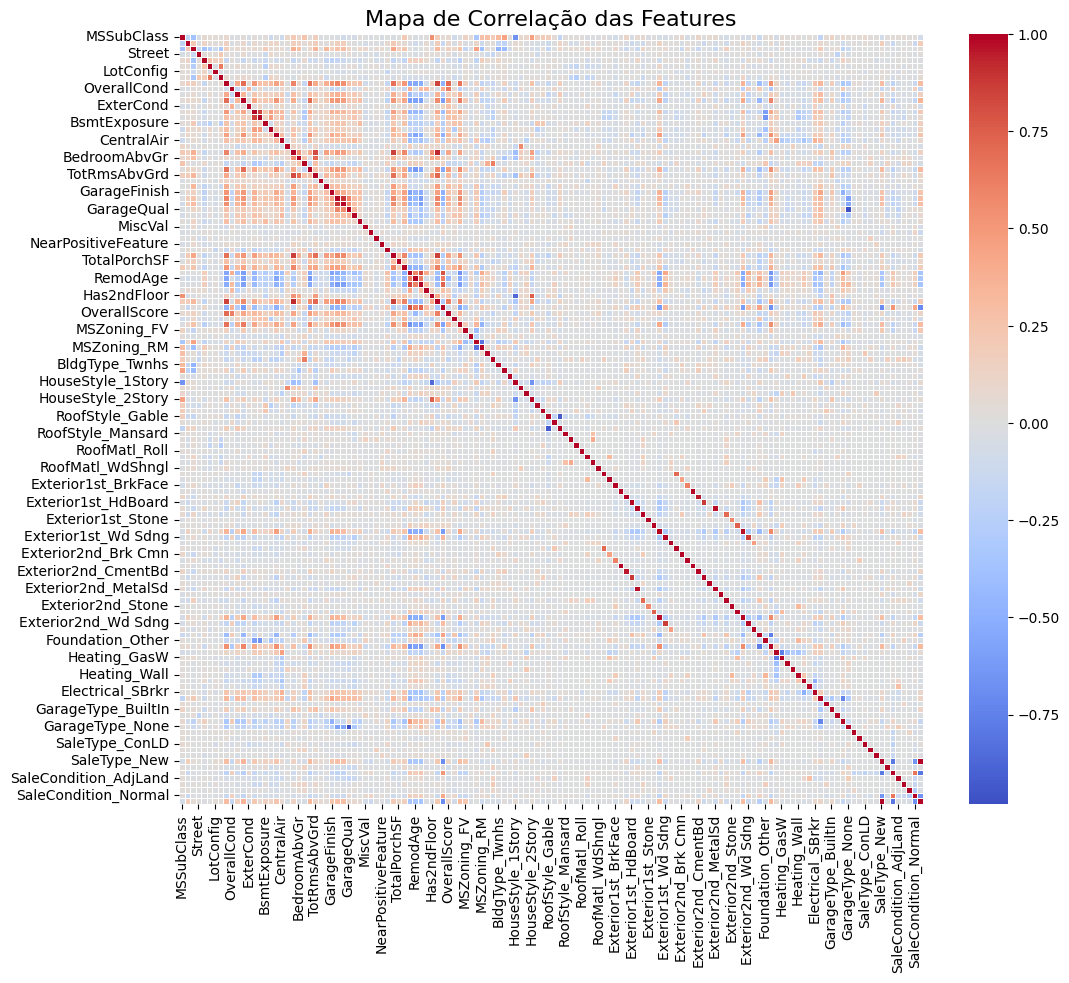

In [1556]:
corr = df_train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlação das Features', fontsize=16)
plt.show()

In [1557]:
from sklearn.model_selection import RandomizedSearchCV
def tune_lasso(X_train, y_train, cv=5):
    """
    Busca o alpha ótimo para Lasso usando LassoCV.
    
    Lasso é especialmente útil quando temos muitas features (200+):
    ele zera os coeficientes de features irrelevantes, atuando como
    um seletor automático de features. 
    
    max_iter alto é necessário pois Lasso usa coordenada descendente
    (não solução analítica como Ridge) e pode precisar de muitas iterações.
    """
    kf       = KFold(n_splits=cv, shuffle=True, random_state=42)
    lasso_cv = LassoCV(alphas=None, cv=kf, max_iter=15_000, random_state=42)
    lasso_cv.fit(X_train, y_train)
    n_selected = np.sum(lasso_cv.coef_ != 0)
    print(f"Melhor alpha para Lasso: {lasso_cv.alpha_:.6f}")
    print(f"Features selecionadas pelo Lasso: {n_selected}/{X_train.shape[1]}")
    return Lasso(alpha=0.000392, max_iter=15_000)
lasso_tuned = tune_lasso(df_train, y_log)
def tune_xgboost(X_train, y_train, cv=5):
    """
    Busca os melhores hiperparâmetros para o XGBoost usando Randomized Search.
    Testa 20 combinações aleatórias para poupar tempo, mas varrendo uma boa área.
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    # 1. O cardápio de opções (A "Grade" de busca)
    param_grid = {
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'n_estimators': [500, 1000, 1500],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5] # Ajuda a evitar overfitting em nós muito pequenos
    }

    # 2. O modelo base
    xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

    # 3. O buscador aleatório
    # n_iter=20 significa que ele vai testar 20 combinações aleatórias. 
    # Se o seu PC for rápido, pode subir para 50!
    xgb_random = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=param_grid,
        n_iter=50, 
        scoring='neg_root_mean_squared_error',
        cv=kf,
        verbose=1, # Mostra o progresso na tela (ex: "Fitting 5 folds for each of 20 candidates")
        random_state=42,
        n_jobs=-1  # Usa todos os núcleos do processador
    )

    print("Iniciando o tuning do XGBoost (isso pode levar alguns minutos)...")
    xgb_random.fit(X_train, y_train)
    
    print("\n✅ Tuning Concluído!")
    print(f"Melhores parâmetros encontrados:")
    for param, value in xgb_random.best_params_.items():
        print(f"  - {param}: {value}")
        
    print(f"\nMelhor RMSE no Cross-Validation: {-xgb_random.best_score_:.5f}")
    
    # Retorna o modelo já configurado com os melhores parâmetros
    return xgb_random.best_estimator_

# Para rodar:
xgb_tuned = tune_xgboost(df_train, y_log)
def tune_ridge(X_train, y_train, cv=5):
    """
    Busca o alpha ótimo para Ridge usando RidgeCV.
    
    Ridge é útil para reduzir a magnitude dos coeficientes sem zerá-los,
    o que pode melhorar a generalização quando há multicolinearidade.
    """
    kf        = KFold(n_splits=cv, shuffle=True, random_state=42)
    ridge_cv  = RidgeCV(alphas=[0.1, 1,2,3,4,5,6,7,8,9, 10,20,30,40,50, 100], cv=kf)
    ridge_cv.fit(X_train, y_train)
    print(f"Melhor alpha para Ridge: {ridge_cv.alpha_}")
    return Ridge(alpha=6)
ridge_tuned = tune_ridge(df_train, y_log)

Melhor alpha para Lasso: 0.000392
Features selecionadas pelo Lasso: 65/134
Iniciando o tuning do XGBoost (isso pode levar alguns minutos)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Tuning Concluído!
Melhores parâmetros encontrados:
  - subsample: 0.7
  - n_estimators: 1500
  - min_child_weight: 1
  - max_depth: 3
  - learning_rate: 0.03
  - colsample_bytree: 0.8

Melhor RMSE no Cross-Validation: 0.10937
Melhor alpha para Ridge: 6.0


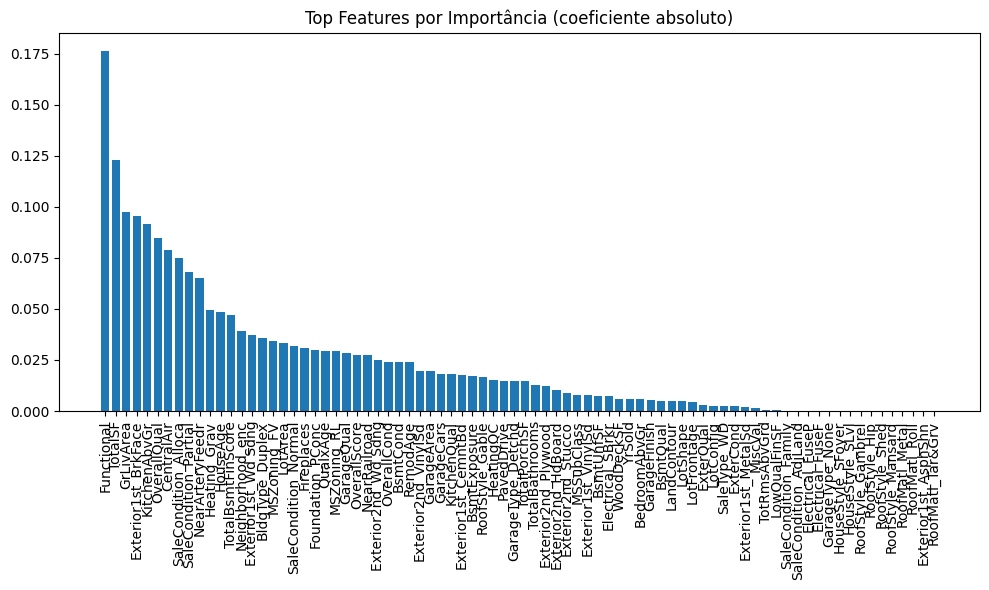

In [1558]:
#Plotando feature importance
def plot_feature_importance(model, feature_names, top_n=50):
    """
    Plota as top_n features mais importantes com base nos coeficientes do modelo.
    Para modelos lineares, a importância é dada pelo valor absoluto dos coeficientes.
    """
    if hasattr(model, "coef_"):
        importance = np.abs(model.coef_)
        indices = np.argsort(importance)[::-1][:top_n]
        plt.figure(figsize=(10, 6))
        plt.bar(range(top_n), importance[indices], align="center")
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=90)
        plt.title("Top Features por Importância (coeficiente absoluto)")
        plt.tight_layout()
        plt.show()
    else:
        print("O modelo não possui coeficientes para calcular a importância.")
# Treina o modelo final com XGBoost tunado para obter os coeficientes
final_model = lasso_tuned.fit(df_train, y_log)
plot_feature_importance(final_model, df_train.columns, top_n=80)

---
## Fase 7 — Predição Final e Submissão

Treinamos o modelo escolhido em **todos os dados de treino** (sem dividir em validação) para aproveitar ao máximo as informações disponíveis.

As predições são feitas no espaço logarítmico e então revertidas com `expm1()` para obter os preços em dólares.

In [1559]:
def predict_and_submit(X_train, y_train, X_test, test_ids, output_path="submission.csv"):
    """
    Treina o modelo final em todos os dados de treino e gera predições.
    
    Por que treinar em todos os dados agora?
    Durante a avaliação (cross-validation), reservamos parte do treino para
    validação. Agora que já escolhemos o modelo e o alpha ideais, podemos
    usar TODOS os dados para treinar o modelo final — isso resulta em um
    modelo marginalmente melhor.
    """
    # 1. Treina os três modelos com TODOS os dados
    lasso_tuned.fit(df_train, y_log)
    ridge_tuned.fit(df_train, y_log) 
    xgb_tuned.fit(df_train, y_log)
    preds_lasso = lasso_tuned.predict(df_test)
    preds_ridge = ridge_tuned.predict(df_test)
    preds_xgb = xgb_tuned.predict(df_test)
    
    preds_log_ensemble = preds_xgb * 0.5 + preds_lasso * 0.3 + preds_ridge * 0.2 
    preds_finais = np.expm1(preds_log_ensemble)
    preds_finais = np.maximum(preds_finais, 0) # Garante que não tem preço negativo

    submission = pd.DataFrame({
    "Id": test_ids.values, 
    "prediction": preds_finais
    })
    submission.to_csv(output_path, index=False)

    print(f"Submissão salva em: '{output_path}'")
    print(f"Estatísticas das predições:")
    print(f"  Mínimo:  ${preds_finais.min():>12,.0f}")
    print(f"  Mediana: ${np.median(preds_finais):>12,.0f}")
    print(f"  Média:   ${preds_finais.mean():>12,.0f}")
    print(f"  Máximo:  ${preds_finais.max():>12,.0f}")
    return submission

submission = predict_and_submit(
    df_train, y_log,
    df_test, test_ids,
    output_path="submission.csv",
)
submission.head(10)

Submissão salva em: 'submission.csv'
Estatísticas das predições:
  Mínimo:  $      49,853
  Mediana: $     155,301
  Média:   $     178,904
  Máximo:  $     637,358


,Id,prediction
0,893,144340.348250
1,1106,340440.502312
2,414,108134.597830
3,523,154320.932945
4,1037,310108.921613
5,615,78310.713687
6,219,233713.246656
7,1161,139314.290143
8,650,78664.131853
9,888,137175.274131


## Resumo do Pipeline



```
Dados brutos
    │
    ├─► [Passo 1] Separação Treino/Teste → Isolamento imediato para evitar Data Leakage.
    │
    ├─► [Passo 2 e 3] Target e Outliers → Remoção de 2 registros extremos (Apenas Treino) + log1p(SalePrice)
    │
    ├─► [Passo 4] Feature Engineering Base → Mapeamentos ordinais numéricos (1 a 5), TotalSF, HouseAge, QualxArea
    │
    ├─► [Passo 5] Encoding Avançado → Target Encoding (K-Fold OOF) p/ Bairros + One-Hot dinâmico com alinhamento
    │
    ├─► [Passo 6] Imputação e Escala → SimpleImputer(median) + log1p(Features Assimétricas) + RobustScaler
    │
    ├─► [Passo 7] Multicolinearidade → Avaliação via VIF e remoção de redundâncias lógicas (ex: HasGarage, GrLivArea)
    │
    └─► [Passo 8] Modelagem e Seleção → Validação Cruzada (RMSE) comparando Ridge, Lasso e XGBoost Regressor
```

## Justificativa da Arquitetura: Por que não usar o Pipeline do Scikit-Learn?
Embora o uso de sklearn.pipeline.Pipeline e ColumnTransformer seja uma prática recomendada para evitar o vazamento de dados (Data Leakage), optamos por uma abordagem customizada e sequencial baseada no Pandas pelos seguintes motivos técnicos:

1. Preservação da Estrutura de DataFrame (Rastreabilidade)
O maior defeito do ColumnTransformer do Scikit-Learn é que ele converte o resultado final em um array do Numpy, apagando o nome de todas as colunas. Como precisávamos realizar etapas de validação intermediárias críticas — como o cálculo de Multicolinearidade (VIF) —, era estritamente necessário manter o formato de pd.DataFrame para saber exatamente quais features estavam causando problemas.

2. Target Encoding com Validação Cruzada (Out-of-Fold)
A técnica de Target Encoding aplicada aos bairros (Neighborhood) utilizou uma lógica K-Fold Out-of-Fold para evitar overfitting. Implementar essa lógica complexa de split diretamente dentro de um Pipeline nativo do Scikit-Learn é excessivamente complexo e engessado, exigindo a criação de classes customizadas (Transformers) que dificultariam a leitura do código.

3. Feature Engineering Complexa e Condicional
Nossa etapa de criação de variáveis (como agrupar categorias raras de Foundation ou criar flags binárias como NearRailroad) depende da interação entre múltiplas colunas de texto nativas. Ferramentas como o get_dummies do Pandas, associadas ao método .align(join='left'), ofereceram uma solução muito mais robusta e legível para lidar com categorias que existem no Treino mas não no Teste, garantindo a mesma dimensionalidade final sem a "caixa preta" do OneHotEncoder.

4. Isolamento do Vazamento de Dados
O risco de Data Leakage foi mitigado manualmente com rigor:

A engenharia de features não utilizou estatísticas globais.

A imputação de nulos (SimpleImputer), o cálculo de assimetria (log1p) e a equalização de variância (RobustScaler) utilizaram o método obrigatório de dar o .fit() exclusivamente no conjunto de Treino, e apenas o .transform() no conjunto de Teste.